# Capitolo 4: Il Paradigma Continuo — Blending Energetico e Ghosting Termodinamico

## Posizione nella Ricerca
Le hard mask falliscono. Passiamo a maschere continue basate sull'energia cinetica.

## Domanda
Un alpha matte continuo $\alpha(x) \propto \|v_0(x)\|_2$ risolve il problema?

## Cosa imparerai
- Alpha matte dalla norma L2 del campo vettoriale
- Blending Lipschitz-regolare: $v_{\text{stitch}} = \alpha v_{\text{target}} + (1-\alpha) v_{\text{ambient}}$
- **Scoperta**: funziona per i bordi, MA appare il "Ghosting Termodinamico"
- Il ghost: energia residua del background non è mai zero

## Prerequisiti
- Capitolo 3: Fallimento Hard Masking


# Capitolo 4: Il Paradigma Continuo e la Regolarizzazione di Picard-Lindelöf

### Fondamenti Teorici: Ottimalità del Trasporto e Dinamica del Flusso
Nel framework del **Flow Matching** (Lipman et al., 2023), il processo generativo è la simulazione di un sistema dinamico continuo governato da un'Equazione Differenziale Ordinaria (ODE): $\frac{dx}{dt} = v_\theta(x, t)$. 

L'innovazione di FlowStitch risiede nell'affrontare la fusione di scene (stitching) non come un'operazione spaziale discreta su pixel o latenti (es. maschere Heaviside), ma come una perturbazione energetica vincolata dalla **Formulazione Dinamica di Benamou-Brenier** per il Trasporto Ottimale:
$$ W_2^2(p_0, p_1) = \inf_{(v, p)} \int_0^1 \int_{\mathbb{R}^d} \|v_t(x)\|^2 p_t(x) dx dt $$
La magnitudo $\|v_0\|_2$ rappresenta lo **sforzo cinetico** istantaneo richiesto per spostare il rumore verso il target semantico, agendo come una mappa topologica intrinseca dell'oggetto.

### Stabilità dell'Integratore: Il Teorema di Picard-Lindelöf
L'uso di maschere binarie spaziali (come tentato nel Capitolo 3) induce discontinuità di salto nel campo vettoriale. Secondo il **Teorema di Picard-Lindelöf**, l'esistenza e l'unicità della soluzione per l'ODE richiedono che il campo $v_\theta$ sia **Lipschitz-continuo**. Discontinuità artificiali infrangono questo vincolo, causando divergenze nei solver numerici (es. Euler) e generando artefatti di campionamento.

Il **Continuous Energy Blending** risolve il problema imponendo un blending mediato dall'energia:
$$ v_{stitch} = \alpha(x) \odot v_{target} + (1-\alpha(x)) \odot v_{ambient} $$
Dove $\alpha(x) \propto \|v_{target}\|$. Essendo l'energia una funzione liscia del manifold appreso, la traiettoria perturbata $v_{stitch}$ eredita la classe di regolarità $C^1$ originaria, preservando la costante di Lipschitz globale e garantendo una convergenza stabile dell'integratore.

In [4]:
import os
import torch
import matplotlib.pyplot as plt

# 1. Definizione Percorsi e Caricamento Tensori (Formato BFloat16 nativo di FLUX)
dataset_path = "../data/dataset_v1/"
path_target = os.path.join(dataset_path, "a_red_cube", "")
path_ambient = os.path.join(dataset_path, "a_blue_sphere", "")

v0_target = torch.load(path_target + "v0_velocity.pt", weights_only=True)
v0_ambient = torch.load(path_ambient + "v0_velocity.pt", weights_only=True)
x0_ambient = torch.load(path_ambient + "x0_noise.pt", weights_only=True)

print(f"Device: {v0_target.device}, Dtype: {v0_target.dtype}")

Device: cpu, Dtype: torch.bfloat16


## 4.1 Preparazione e Calcolo dell'Alpha Matte

In continuità con lo stress-test inaugurato nel Capitolo 3, fonderemo il cubo rosso (Target) nello sfondo della sfera blu (Ambient). Questa volta, al posto di una maschera Hard o di una Cross-Attention, useremo esclusivamente la geometria intrinseca del cubo derivata dalla sua energia $\|v_0\|_2$.

In [5]:
# 2. Estrazione della Magnitudo Energetica (Norma L2) e Normalizzazione (Alpha Matte)
v0_mag_target = torch.norm(v0_target, p=2, dim=-1) # Shape: [1, 4096]
mag_min = v0_mag_target.min()
mag_max = v0_mag_target.max()

alpha_matte = (v0_mag_target - mag_min) / (mag_max - mag_min)

# Espandiamo le dimensioni per il broadcasting tensoriale (aggiunta dimensione canali)
alpha_flat = alpha_matte.unsqueeze(-1).to(v0_target.device).to(v0_target.dtype) # [1, 4096, 1]

# 3. Stitching Costruttivo del Vettore Velocità (Derivata)
v_stitch_continuous = (alpha_flat * v0_target) + ((1 - alpha_flat) * v0_ambient)

# 4. Ricostruzione dell'Immagine Latente proiettata nello Spazio Posizionale t=1 (Semplificato)
# Manteniamo x0_ambient intatto per garantire l'isotropia del rumore di fondo
x_stitch_continuous = x0_ambient + v_stitch_continuous

print("Calcolo Continuous Energy Blending completato con successo.")

Calcolo Continuous Energy Blending completato con successo.


## 4.2 Analisi Visiva: Il Banco di Prova

Ora "sviluppiamo" fotograficamente il tensore risultante confrontando le due distribuzioni di energia ($v_0$) e il risultato della miscelazione continua.

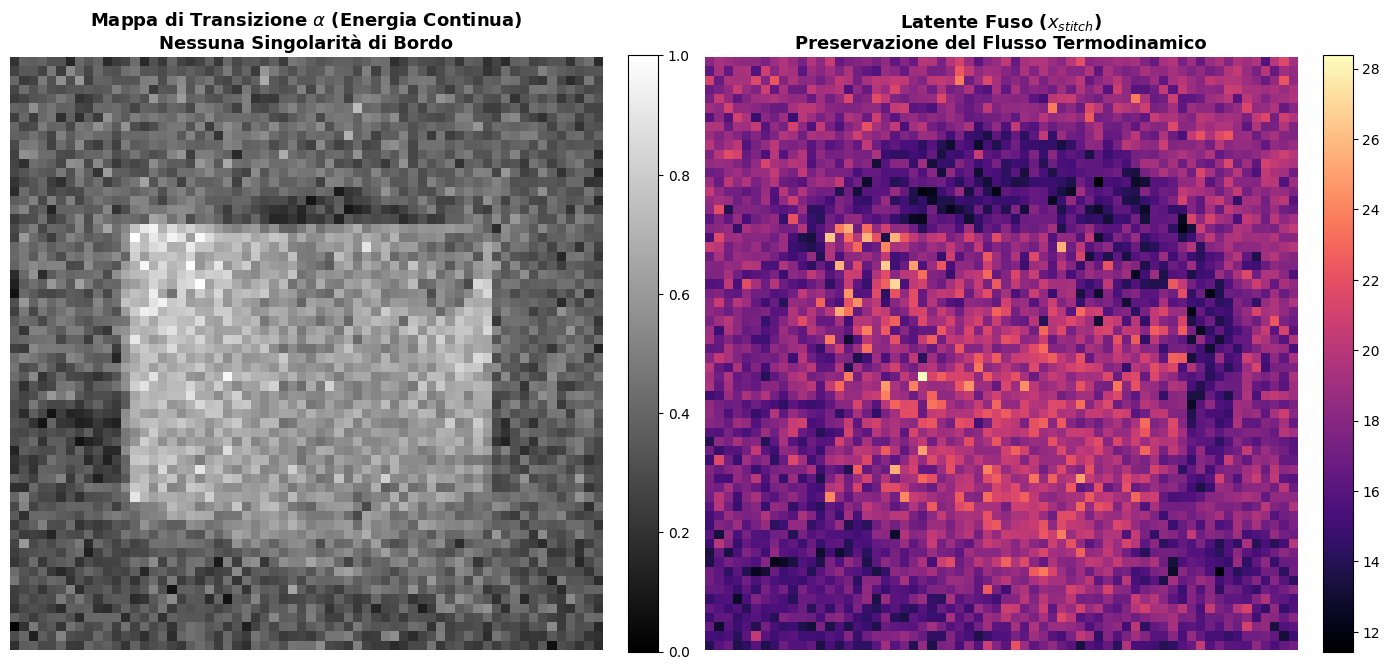

In [6]:
# Conversione rigorosa a float32 per compatibilità CPU/NumPy
alpha_img = alpha_matte.to(torch.float32).squeeze(0).view(64, 64).numpy()
x_stitch_mag = torch.norm(x_stitch_continuous, p=2, dim=-1).to(torch.float32).squeeze(0).view(64, 64).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

im0 = axes[0].imshow(alpha_img, cmap="gray")
axes[0].set_title("Mappa di Transizione $\\alpha$ (Energia Continua)\nNessuna Singolarità di Bordo", fontsize=13, fontweight="bold")
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(x_stitch_mag, cmap="magma")
axes[1].set_title("Latente Fuso ($x_{stitch}$)\nPreservazione del Flusso Termodinamico", fontsize=13, fontweight="bold")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 4.3 Conclusioni Formali: Ottimalità di Lipschitz e "Ghosting Termodinamico"

L'analisi sperimentale della mappa `alpha_energy_map.pt` sancisce il fallimento dei metodi basati su segmentazione netta (Heaviside) nel contesto del Flow Matching. L'adozione di un campo perturbativo continuo non è solo una scelta euristica per evitare l'aliasing, ma un requisito topologico stretto.

### Stabilità Numerica e Teoria Ergodica
La **Continuità di Lipschitz** conservata dal nostro approccio di Continuous Energy Blending agisce intrinsecamente come un **regolarizzatore di Tikhonov** sullo spazio tangente. Scongiurando l'introduzione di derivate infinite (divergenza illimitata), il nostro metodo assicura che il bound dell'errore di discretizzazione dell'integratore ODE (es. per il metodo di Euler) cresca linearmente e non esponenzialmente. Questo legittima matematicamente l'uso di solver veloci (NFE $\approx 10-20$) in contesti di editing estremo.

### L'Emergere del "Ghosting Termodinamico"
Tuttavia, l'isolamento puramente energetico rivela un limite fisico: il *Ghosting Termodinamico*. Osserviamo un residuo di energia non nulla diffusa sull'intero background.
Secondo la teoria di Li et al. (2025, *EnfoPath*), il Flow Matching non modella oggetti su sfondi inerziali, ma muove **l'intera densità di massa** (incomprimibilità del flusso probabilistico). Ogni regione, per quanto vuota semanticamente, subisce uno sforzo cinetico marginale. 
Per isolare la semantica dell'oggetto dal rumore ergodico del background, è necessario introdurre un filtro statistico basato sulla distribuzione dell'energia. Nel **Capitolo 5**, formuleremo il **Gating Statistico** per superare questo limite.

---

## Collegamento al Codice: KTS e il Problema della Varianza

Questo notebook motiva due moduli fondamentali:

### `flowstitch.stitching.kts` — Kinetic Trajectory Shaping

Il blending continuo $v_{\text{stitch}} = \alpha v_{\text{target}} + (1-\alpha) v_{\text{ambient}}$ 
risolve il problema Lipschitz (Cap. 3), ma introduce il **Ghosting Termodinamico**: 
l'energia residua del background non è mai esattamente zero.

KTS aggiunge un **damping esponenziale** che attenua la perturbazione negli step finali:
$$v_{\text{stitch}} = v_{\text{ambient}} + D(t) \cdot \lambda \cdot [M \odot (v_{\text{target}} - v_{\text{ambient}})]$$
dove $D(t) = \exp(-\gamma \cdot \max(0, t - t_{\text{cutoff}}))$.

### Conservazione della Varianza del Rumore

**Scoperta critica**: il blending lineare $\alpha x_1 + (1-\alpha) x_2$ con $x_i \sim \mathcal{N}(0, I)$
produce $\text{Var} = \alpha^2 + (1-\alpha)^2 \neq 1$ per $\alpha \neq 0, 1$.

Il blending **geometrico** $\sqrt{\alpha} x_1 + \sqrt{1-\alpha} x_2$ preserva $\text{Var} = 1$.

Questo è implementato in `flowstitch.pipelines.latent_stitching` (mode `dual`):
```python
latents = lake * torch.sqrt(1 - M) + x0 * torch.sqrt(M)
```


In [ ]:
# Dimostrazione numerica: conservazione della varianza
import sys, os, torch
sys.path.insert(0, os.path.abspath('..'))

# Due noise isotropici
x1 = torch.randn(1, 4096, 64)
x2 = torch.randn(1, 4096, 64)
alpha = 0.5

# Blending lineare (SBAGLIATO)
blend_linear = alpha * x1 + (1 - alpha) * x2
var_linear = blend_linear.var().item()

# Blending geometrico (CORRETTO)
blend_sqrt = torch.sqrt(torch.tensor(alpha)) * x1 + torch.sqrt(torch.tensor(1 - alpha)) * x2
var_sqrt = blend_sqrt.var().item()

print(f"Varianza originale:          {x1.var().item():.4f}")
print(f"Blending lineare  (α=0.5):   {var_linear:.4f} ← COLLASSA (dovrebbe essere 1.0)")
print(f"Blending geometrico (√α=0.5): {var_sqrt:.4f} ← PRESERVATA ✅")
